# 05 — Classification
### IndicNews AI — Hindi News Analysis, Retrieval & Recommendation System

Trains a multi-label news category classifier on top of the 
TF-IDF features and  `core_categories` labels. 

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_utils import load_dataset
from preprocessing import preprocess_pipeline, preprocess_text
from feature_engineering import finalize_tokens_for_features
from classification import (
    load_features_and_labels, train_classifier, evaluate_classifier,
    save_classifier_bundle, predict_categories,
)

pd.set_option("display.max_colwidth", 80)

## 1. Rebuild `clean_df` — must match Module 4's exact row order

`tfidf_matrix.npz` has no labels saved alongside it, so we regenerate
`clean_df` with the *exact* same sequence 
(`load_dataset` → `drop_duplicates` → `reset_index` → `preprocess_pipeline`)
and let `load_features_and_labels()` assert the row counts match before
proceeding catching silent misalignment early rather than training
against shuffled labels.

In [2]:
df = load_dataset(verbose=False)
uniq = df.drop_duplicates(subset=["Headline", "Content"]).reset_index(drop=True)
clean_df = preprocess_pipeline(uniq, columns=["Headline", "Content"])
print(clean_df.shape)

(34826, 11)


In [3]:
X, Y, mlb = load_features_and_labels(clean_df)
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Classes:", list(mlb.classes_))

X shape: (34826, 60359)
Y shape: (34826, 7)
Classes: ['business', 'entertainment', 'national', 'other', 'politics', 'sports', 'technology']


## 2. Label distribution check

Sanity-check the class balance carried over from  EDA before
training technology was flagged as the smallest class there.

In [4]:
class_counts = pd.Series(Y.sum(axis=0), index=mlb.classes_).sort_values(ascending=False)
print(class_counts)
print()
print("Rows with 2+ labels:", (Y.sum(axis=1) >= 2).sum(), f"({(Y.sum(axis=1) >= 2).mean():.1%})")

national         14761
sports            5591
entertainment     5091
politics          5040
other             4535
business          3596
technology        1702
dtype: int64

Rows with 2+ labels: 5410 (15.5%)


## 3. Train/test split

Plain random split (`test_size=0.2`, fixed seed) 

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)

train_dist = pd.Series(Y_train.sum(axis=0), index=mlb.classes_) / len(Y_train)
test_dist = pd.Series(Y_test.sum(axis=0), index=mlb.classes_) / len(Y_test)
pd.DataFrame({"train_share": train_dist, "test_share": test_dist}).round(3)

Train: (27860, 60359)  Test: (6966, 60359)


,train_share,test_share
business,0.103,0.104
entertainment,0.146,0.149
national,0.422,0.430
other,0.132,0.123
politics,0.145,0.145
sports,0.161,0.160
technology,0.049,0.049


## 4. Train the classifier

`OneVsRestClassifier(LogisticRegression(class_weight="balanced"))`
one binary classifier per category, class-weighted to account for the
imbalance seen in §2.

In [6]:
import time
t0 = time.time()
model = train_classifier(X_train, Y_train)
print(f"Trained in {time.time() - t0:.1f}s")

Trained in 3.5s


## 5. Evaluate

Per-class precision/recall/F1, micro/macro/weighted F1, Hamming loss,
and **subset accuracy** (fraction of rows where every predicted label
matched exactly  expect this to be meaningfully lower than per-label
metrics, since it's a much stricter bar on a genuinely multi-label
problem).

In [8]:
results = evaluate_classifier(model, X_test, Y_test, class_names=list(mlb.classes_))
print(results["report"])
print(f"Micro F1:        {results['micro_f1']:.4f}")
print(f"Macro F1:         {results['macro_f1']:.4f}")
print(f"Weighted F1:      {results['weighted_f1']:.4f}")
print(f"Hamming loss:     {results['hamming_loss']:.4f}")
print(f"Subset accuracy:  {results['subset_accuracy']:.4f}")

               precision    recall  f1-score   support

     business       0.74      0.90      0.81       725
entertainment       0.92      0.95      0.93      1036
     national       0.84      0.89      0.87      2997
        other       0.63      0.86      0.73       859
     politics       0.71      0.88      0.78      1012
       sports       0.97      0.96      0.97      1116
   technology       0.66      0.85      0.74       341

    micro avg       0.80      0.90      0.85      8086
    macro avg       0.78      0.90      0.83      8086
 weighted avg       0.81      0.90      0.85      8086
  samples avg       0.84      0.91      0.86      8086

Micro F1:        0.8495
Macro F1:         0.8329
Weighted F1:      0.8536
Hamming loss:     0.0530
Subset accuracy:  0.7103


### 5.1 Per-class confusion matrices

One 2×2 matrix per class (not a single NxN matrix — that's only
meaningful for single-label problems). Each shows
`[[TN, FP], [FN, TP]]` for that class treated as a binary
present/absent decision.

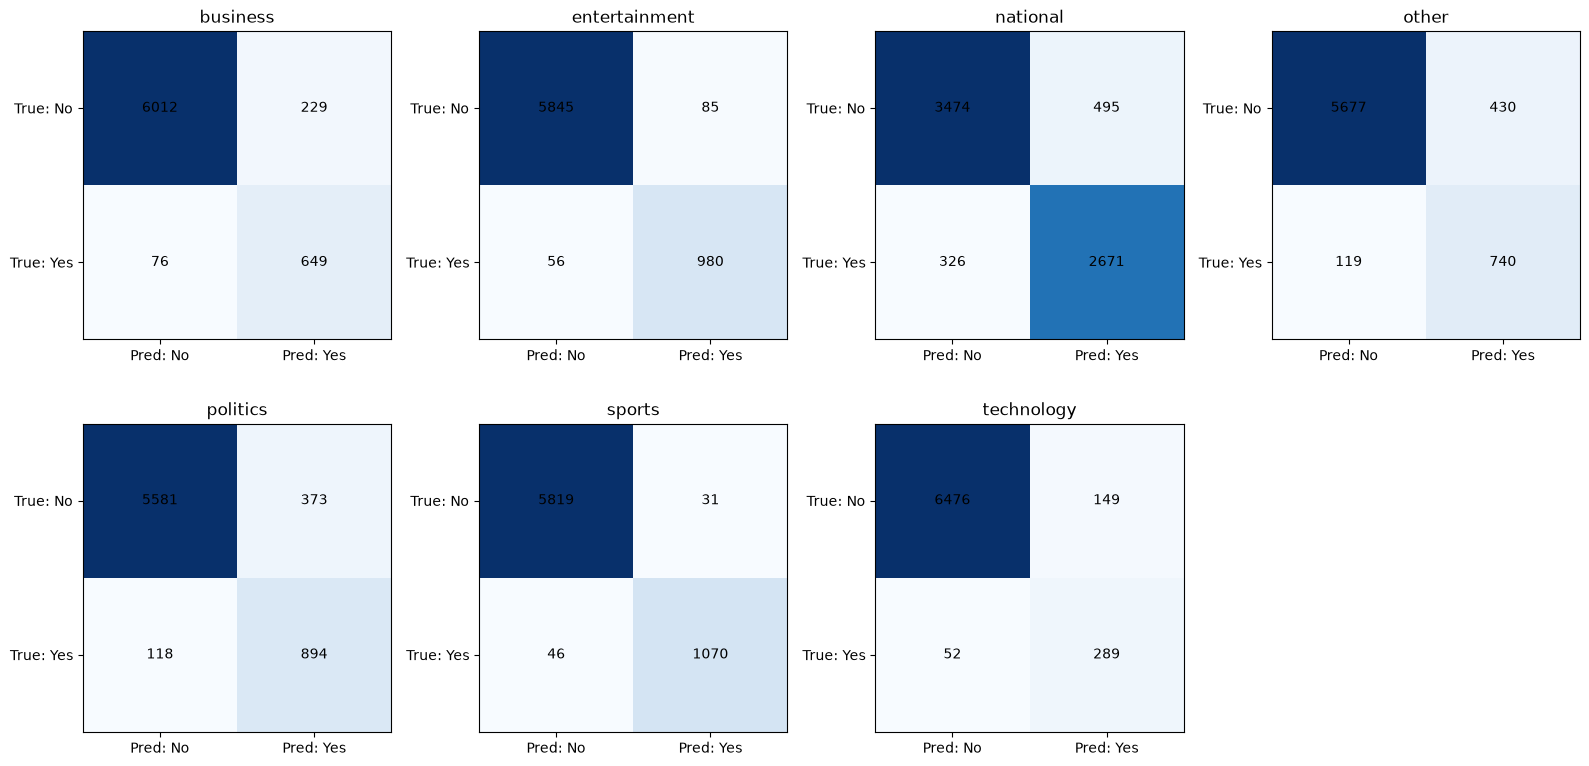

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, (cls, cm) in enumerate(zip(mlb.classes_, results["confusion_matrices"])):
    ax = axes.flat[i]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(cls)
    for (r, c), val in np.ndenumerate(cm):
        ax.text(c, r, val, ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: No", "Pred: Yes"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["True: No", "True: Yes"])
axes.flat[-1].axis("off")  
plt.tight_layout()
plt.show()

## 6. Save the classifier bundle

In [11]:
save_classifier_bundle(model, mlb)
import os
size_mb = os.path.getsize("../../models/saved_models/classifier.joblib") / 1e6
print(f"Saved classifier.joblib ({size_mb:.1f} MB)")

Saved classifier.joblib (3.4 MB)


## 7. Inference demo 

In [10]:
import joblib
tfidf_vectorizer = joblib.load("../../models/saved_models/tfidf_vectorizer.joblib")

sample_texts = [
    "भारतीय क्रिकेट टीम ने आज मैच में शानदार जीत दर्ज की",
    "शेयर बाजार में आज तेजी देखी गई और सेंसेक्स नए रिकॉर्ड पर पहुंचा",
    "प्रधानमंत्री ने आज नई शिक्षा नीति पर बैठक की अध्यक्षता की",
]

for text in sample_texts:
    preds = predict_categories(
        text,
        tfidf_vectorizer,
        model,
        mlb,
        preprocess_fn=lambda t: preprocess_text(t)[1],
        finalize_fn=finalize_tokens_for_features,
        threshold=0.3,
    )
    print(text)
    print(" ->", preds)
    print()

भारतीय क्रिकेट टीम ने आज मैच में शानदार जीत दर्ज की
 -> [('sports', 99.5)]

शेयर बाजार में आज तेजी देखी गई और सेंसेक्स नए रिकॉर्ड पर पहुंचा
 -> [('business', 78.7)]

प्रधानमंत्री ने आज नई शिक्षा नीति पर बैठक की अध्यक्षता की
 -> [('politics', 67.2), ('national', 37.2)]



## 8. Summary

- **Micro F1: 0.850** · **Macro F1: 0.833** · **Weighted F1: 0.854**
- **Hamming loss: 0.053**  only 5.3% of individual label decisions wrong
- **Subset accuracy: 0.710**  71% of test articles got *every* label
  exactly right (a strict bar for multi-label; expected to trail the
  per-label metrics, and it does)
- **Multi-label rate:** 15.5% of all rows carry 2+ category labels 
  confirms the multi-label design decision was necessary, not
  just theoretically nice

**Per-class pattern:** `sports` (F1 0.97) and `entertainment` (0.93) are
excellent distinctive vocabulary, easy to separate. `technology`
(0.74), `other` (0.73), `business` (0.81), and `politics` (0.78) all
share the same signature: **high recall, lower precision** (e.g.
technology: 85% recall, 66% precision). That's the expected side-effect
of `class_weight="balanced"`  it pushes the model to catch more true
positives in smaller/fuzzier classes at the cost of some false
positives. `other` being weakest also makes sense structurally: it's
 residual bucket (national/world/misc/event tags lumped
together), so it has no coherent internal topic for the model to learn
clean boundaries around — unlike the other six labeled categories.

**Confusion matrix confirms the same story numerically**  e.g.
`technology`: 289 true positives vs 149 false positives (precision-limiting)
but only 52 false negatives (recall stays high); `national`, by far the
largest class (2997 support), still shows the same shape (326 FN vs 495
FP) rather than dominating trivially.

**§7 inference demo — the multi-label design paying off in practice:**
the PM/education-policy headline correctly received **both**
`politics` (67.2%) and `national` (37.2%) exactly the co-occurrence
pattern EDA found in the real data, not a coincidence. Train
vs. test class-share table (§3) confirms the random split didn't skew
any class (largest gap: `other` at 13.2% train vs 12.3% test) —no need
for the heavier iterative-stratification machinery.

**Overall:** strong result for a project scope with a
straightforward Logistic Regression baseline. If pushed further,
`other`/`technology`/`business` precision would be the place to
invest  e.g. tuning per-class thresholds instead of a flat 0.5, or
trying LinearSVC with calibration for comparison.

